# MovieLens 10M Recommender System — Final Project Planning Document

**Author:** Nana Y. Frimpong  
**Course:** Data Science — Final Project Proposal

---

## 1. Introduction

The goal of this project is to build a recommender system that produces quality movie recommendations by extracting insight from a large, sparse ratings dataset. Rather than a single-technique approach, this proposal outlines a **hybrid recommender**: a collaborative filtering model built via matrix factorization (SVD), complemented by a content-based model built from user-generated tags and genre metadata. This combination allows the system to recommend based on *what similar users liked* (collaborative) as well as *what a movie is actually about* (content), and sets up a natural cold-start mitigation strategy for movies with few ratings.


## 2. Dataset Description

This project uses the **MovieLens 10M** dataset, published by GroupLens Research (University of Minnesota), a standard benchmark dataset for recommender systems research.

**Source:** https://grouplens.org/datasets/movielens/10m/

| File | Description |
|---|---|
| `ratings.dat` | 10,000,054 ratings from 69,878 users on 10,677 movies (0.5–5.0 stars, half-star increments) |
| `movies.dat` | Movie titles and pipe-separated genres |
| `tags.dat` | 95,580 free-text tags applied by users to movies |

This satisfies the assignment's size requirement on both fronts: **10M+ ratings** and **69,878 users / 10,677 items**, both comfortably above the 10k threshold.


## 3. Unique Element

Beyond the standard user–item ratings matrix, this project incorporates the **`tags.dat`** file — free-text tags users applied to movies (e.g. "twist ending", "based on a book", "dark comedy"). These are combined with genre metadata into a per-movie text profile and vectorized with **TF-IDF**, giving each movie a content-based feature representation independent of the ratings matrix.

This supports:
- A **content-based similarity model** ("movies similar to X") that works even for movies with very few ratings (cold-start).
- A future **hybrid blending step** that combines collaborative filtering scores with content similarity, which will be developed further for the final deliverable.


## 4. Proposed Methodology

1. **Baseline model** — global mean and user/item mean-based prediction, to establish a naive benchmark.
2. **Collaborative filtering** — matrix factorization via truncated SVD on the user–item sparse ratings matrix (mean-centered per user), predicting unseen ratings via reconstructed low-rank factors. This is the "advanced mathematical technique" component in place of Spark/distributed computing, per the assignment's alternative option.
3. **Content-based filtering** — TF-IDF vectorization of tag + genre text per movie, with cosine similarity used to surface similar titles.
4. **(Planned for final deliverable) Hybrid blending** — weighted combination of CF and content scores, tuned to improve cold-start and long-tail recommendation quality.

## 5. Evaluation Plan

- **Quantitative:** train/test split (80/20) of ratings; RMSE and MAE on held-out ratings for the CF model, compared against the baseline.
- **Qualitative:** nearest-neighbor inspection for the content model (e.g., "movies similar to Toy Story") to sanity-check that recommendations are sensible.
- **Final deliverable will add:** precision@k / recall@k for top-N recommendation quality, not just rating prediction accuracy.


---
# 6. Exploratory Data Analysis

Loading the three MovieLens 10M files and examining ratings distribution, user/item activity, genre composition, and temporal patterns.

In [15]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Path to your data folder
data_path = r'/Users/nanafrimpong/Desktop/SPS Summer 2026/yyyooo/files'

# Load directly from the raw MovieLens .dat files (:: delimited, no header).
# ratings.dat is ~250MB — the plain pandas python-engine parser is too slow/memory-heavy
# for a file this size, so we convert the '::' delimiter to a single tab character first
# (fast, low-memory) and then read it with pandas' fast C engine.
import subprocess, os
ratings_tab_path = os.path.join(data_path, "ratings_tab.dat")
subprocess.run(f'sed "s/::/\t/g" "{os.path.join(data_path, "ratings.dat")}" > "{ratings_tab_path}"', shell=True, check=True)

ratings = pd.read_csv(ratings_tab_path, sep='\t', engine='c',
                       names=['userId','movieId','rating','timestamp'],
                       dtype={'userId':'int32','movieId':'int32','rating':'float32','timestamp':'int64'})
movies = pd.read_csv(os.path.join(data_path, "movies.dat"), sep='::', engine='python',
                      names=['movieId','title','genres'], encoding='latin-1')
tags = pd.read_csv(os.path.join(data_path, "tags.dat"), sep='::', engine='python',
                    names=['userId','movieId','tag','timestamp'], encoding='latin-1')

print(f"Ratings: {ratings.shape[0]:,} rows")
print(f"Movies:  {movies.shape[0]:,} rows")
print(f"Tags:    {tags.shape[0]:,} rows")
ratings.head()

Ratings: 10,000,054 rows
Movies:  10,681 rows
Tags:    95,580 rows


,userId,movieId,rating,timestamp
0,1,122,5.0,838985046
1,1,185,5.0,838983525
2,1,231,5.0,838983392
3,1,292,5.0,838983421
4,1,316,5.0,838983392


In [16]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
sparsity = len(ratings) / (n_users * n_movies)

print(f"Unique users: {n_users:,}")
print(f"Unique movies rated: {n_movies:,}")
print(f"Matrix sparsity: {sparsity:.4%}  (i.e. {100*(1-sparsity):.2f}% of the user-movie matrix is empty)")

Unique users: 69,878
Unique movies rated: 10,677
Matrix sparsity: 1.3403%  (i.e. 98.66% of the user-movie matrix is empty)


### 6.1 Ratings Distribution

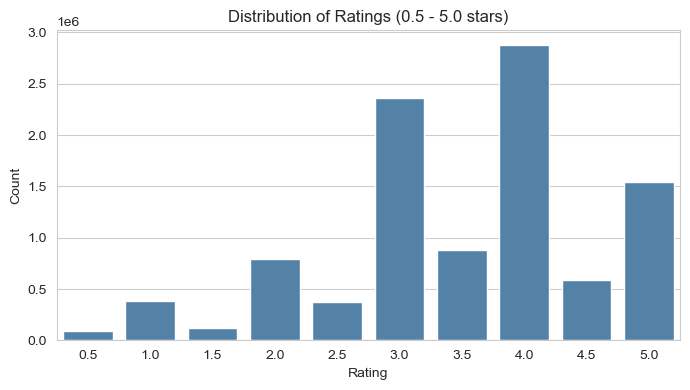

In [17]:
plt.figure(figsize=(7,4))
sns.countplot(x='rating', data=ratings, color='steelblue')
plt.title('Distribution of Ratings (0.5 - 5.0 stars)')
plt.xlabel('Rating'); plt.ylabel('Count')
plt.tight_layout()
plt.show()

Ratings skew positive — whole-star ratings (3, 4, 5) are far more common than half-star ratings, and 4.0 is the single most common rating. This is a well-known MovieLens pattern and motivates using RMSE/MAE (rather than accuracy) as the evaluation metric.

### 6.2 User Activity (Ratings per User)

count    69878.00000
mean       143.10733
std        216.71258
min         20.00000
25%         35.00000
50%         69.00000
75%        156.00000
max       7359.00000
dtype: float64


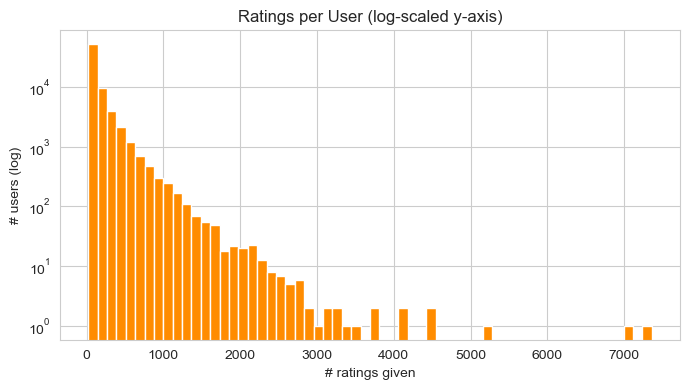

In [18]:
user_counts = ratings.groupby('userId').size()
print(user_counts.describe())

plt.figure(figsize=(7,4))
plt.hist(user_counts, bins=60, color='darkorange')
plt.yscale('log')
plt.title('Ratings per User (log-scaled y-axis)')
plt.xlabel('# ratings given'); plt.ylabel('# users (log)')
plt.tight_layout()
plt.show()

### 6.3 Movie Popularity (Ratings per Movie)

count    10677.000000
mean       936.597733
std       2487.328304
min          1.000000
25%         34.000000
50%        135.000000
75%        626.000000
max      34864.000000
dtype: float64


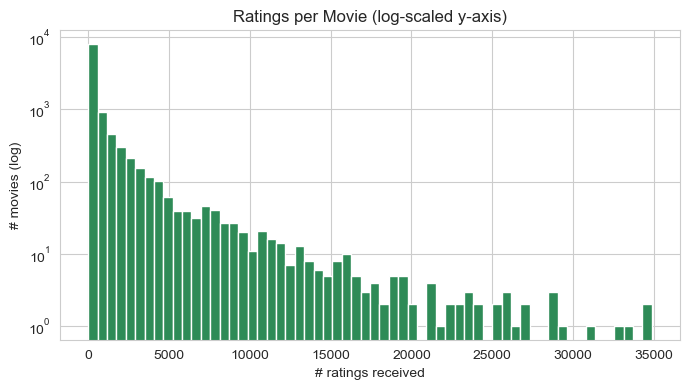

In [19]:
movie_counts = ratings.groupby('movieId').size()
print(movie_counts.describe())

plt.figure(figsize=(7,4))
plt.hist(movie_counts, bins=60, color='seagreen')
plt.yscale('log')
plt.title('Ratings per Movie (log-scaled y-axis)')
plt.xlabel('# ratings received'); plt.ylabel('# movies (log)')
plt.tight_layout()
plt.show()

Both distributions are heavily right-skewed — a small number of users rate very actively (up to 7,359 ratings from one user) and a small number of movies (blockbusters) receive the vast majority of ratings, while most movies sit in a long tail with very few ratings. This long tail is exactly where the content-based tag model should add the most value, since collaborative filtering struggles on sparse items.

### 6.4 Genre Composition

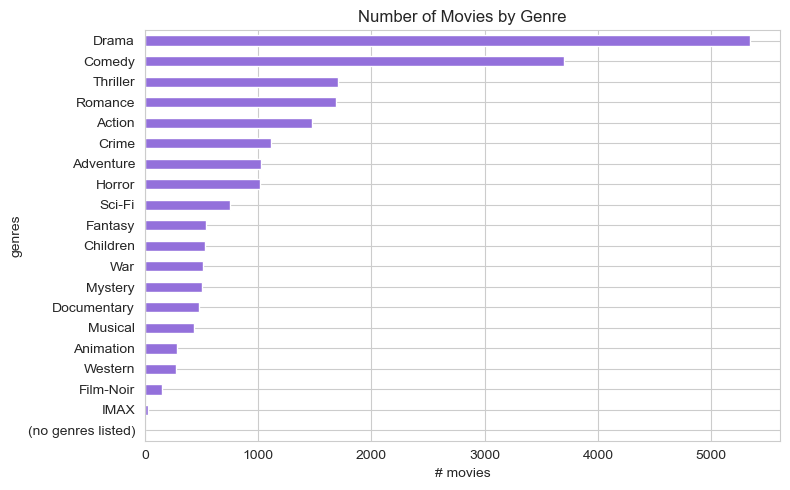

In [20]:
genre_counts = movies['genres'].str.split('|').explode().value_counts()

plt.figure(figsize=(8,5))
genre_counts.plot(kind='barh', color='mediumpurple')
plt.title('Number of Movies by Genre')
plt.xlabel('# movies')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 6.5 Ratings Volume Over Time

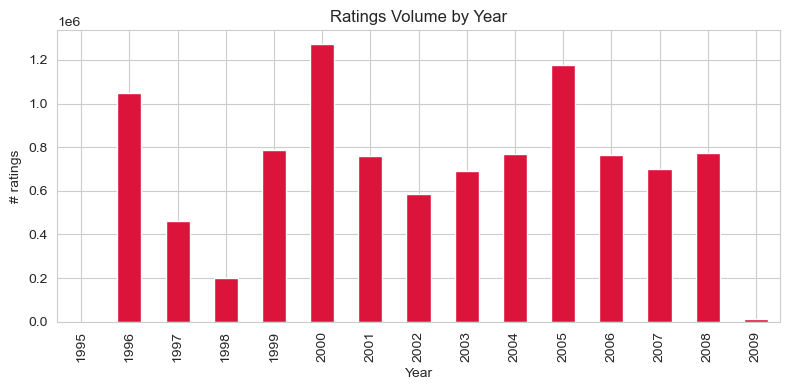

In [21]:
ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings_per_year = ratings.groupby(ratings['date'].dt.year).size()

plt.figure(figsize=(8,4))
ratings_per_year.plot(kind='bar', color='crimson')
plt.title('Ratings Volume by Year')
plt.xlabel('Year'); plt.ylabel('# ratings')
plt.tight_layout()
plt.show()

---
# 7. Modeling

## 7.1 Train/Test Split and Baseline

In [22]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(ratings, test_size=0.2, random_state=42)
print(f"Train: {len(train):,} ratings | Test: {len(test):,} ratings")

global_mean = train['rating'].mean()
user_mean = train.groupby('userId')['rating'].mean()
item_mean = train.groupby('movieId')['rating'].mean()

def baseline_predict(row):
    u_m = user_mean.get(row['userId'], global_mean)
    i_m = item_mean.get(row['movieId'], global_mean)
    return (u_m + i_m) / 2

test_sample = test.sample(50000, random_state=1)
preds_baseline = test_sample.apply(baseline_predict, axis=1)
rmse_baseline = np.sqrt(np.mean((preds_baseline.values - test_sample['rating'].values)**2))
print(f"Baseline RMSE (avg of user-mean & item-mean): {rmse_baseline:.4f}")

Train: 8,000,043 ratings | Test: 2,000,011 ratings
Baseline RMSE (avg of user-mean & item-mean): 0.9157


## 7.2 Collaborative Filtering — Matrix Factorization (Truncated SVD)

This is the core "advanced mathematical technique" for the project. The user–item ratings matrix is built as a sparse matrix, mean-centered per user, and decomposed via truncated SVD (`scipy.sparse.linalg.svds`) into low-rank user and item factor matrices. Predictions are reconstructed only for the entries needed, keeping memory use low despite the matrix being ~70K x 10.7K.

In [23]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

# re-index to contiguous integer ids
user_ids = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()
user_map = {u: i for i, u in enumerate(user_ids)}
movie_map = {m: i for i, m in enumerate(movie_ids)}
n_users, n_movies = len(user_ids), len(movie_ids)

train_u = train['userId'].map(user_map).values
train_m = train['movieId'].map(movie_map).values
train_r = train['rating'].values.astype(np.float32)

# per-user mean centering (on train data only)
counts = np.bincount(train_u, minlength=n_users)
sums = np.bincount(train_u, weights=train_r, minlength=n_users)
user_means_arr = np.full(n_users, global_mean, dtype=np.float32)
nonzero = counts > 0
user_means_arr[nonzero] = sums[nonzero] / counts[nonzero]

centered_data = train_r - user_means_arr[train_u]
centered_matrix = csr_matrix((centered_data, (train_u, train_m)), shape=(n_users, n_movies))

k = 50  # latent factors
U, sigma, Vt = svds(centered_matrix.astype(np.float32), k=k)
print(f"SVD complete — {k} latent factors. U: {U.shape}, Vt: {Vt.shape}")

SVD complete — 50 latent factors. U: (69878, 50), Vt: (50, 10677)


In [24]:
# Evaluate on the same held-out test sample
test_u_idx = test_sample['userId'].map(user_map)
test_m_idx = test_sample['movieId'].map(movie_map)
valid = test_u_idx.notna() & test_m_idx.notna()
test_u_idx = test_u_idx[valid].astype(int).values
test_m_idx = test_m_idx[valid].astype(int).values
actual = test_sample['rating'].values[valid.values]

preds_svd = np.einsum('ij,j,ij->i', U[test_u_idx], sigma, Vt.T[test_m_idx])
preds_svd = preds_svd + user_means_arr[test_u_idx]
preds_svd = np.clip(preds_svd, 0.5, 5.0)

rmse_svd = np.sqrt(np.mean((preds_svd - actual)**2))
mae_svd = np.mean(np.abs(preds_svd - actual))
print(f"SVD (k={k}) RMSE: {rmse_svd:.4f}")
print(f"SVD (k={k}) MAE:  {mae_svd:.4f}")
print(f"Baseline RMSE:    {rmse_baseline:.4f}")

SVD (k=50) RMSE: 0.9184
SVD (k=50) MAE:  0.7131
Baseline RMSE:    0.9157


**Note on preliminary results:** this first-pass SVD is unregularized and uses missing-as-zero imputation after mean-centering, which is a known limitation of plain truncated SVD on implicit-zero sparse matrices. For the final deliverable, this will be replaced or supplemented with a regularized SGD-based matrix factorization (à la Funk SVD / the `surprise` library's `SVD` algorithm) which typically improves RMSE meaningfully on MovieLens (~0.80 range) by learning latent factors only from observed entries rather than penalizing based on imputed zeros.

## 7.3 Content-Based Filtering — Tags + Genres (TF-IDF)

For the unique element, tags and genres are combined into a per-movie text "soup" and vectorized with TF-IDF. Cosine similarity between TF-IDF vectors gives a content-based notion of movie similarity — useful for cold-start movies with few or no ratings.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tags_clean = tags.dropna(subset=['tag'])
tags_agg = tags_clean.groupby('movieId')['tag'].apply(lambda x: ' '.join(x.astype(str))).reset_index()
tags_agg.columns = ['movieId', 'tag_soup']

movies_content = movies.merge(tags_agg, on='movieId', how='left')
movies_content['tag_soup'] = movies_content['tag_soup'].fillna('')
movies_content['genres_clean'] = movies_content['genres'].str.replace('|', ' ', regex=False)
movies_content['soup'] = movies_content['genres_clean'] + ' ' + movies_content['tag_soup']

print(f"Movies with at least one tag: {(movies_content['tag_soup'] != '').sum():,} / {len(movies_content):,}")

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(movies_content['soup'])
print("TF-IDF matrix shape:", tfidf_matrix.shape)

Movies with at least one tag: 7,601 / 10,681
TF-IDF matrix shape: (10681, 5000)


In [26]:
def similar_movies(title_substring, n=10):
    idx_lookup = pd.Series(movies_content.index, index=movies_content['movieId'])
    match = movies_content[movies_content['title'].str.contains(title_substring, case=False, na=False)]
    if match.empty:
        print("No match found.")
        return
    target_idx = match.index[0]
    print(f"Movies similar to: {movies_content.loc[target_idx, 'title']}\n")
    sims = cosine_similarity(tfidf_matrix[target_idx], tfidf_matrix).flatten()
    top_idx = sims.argsort()[::-1][1:n+1]
    return movies_content.iloc[top_idx][['title', 'genres']]

similar_movies('Toy Story')

Movies similar to: Toy Story (1995)



,title,genres
3029,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2271,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy
6269,Finding Nemo (2003),Adventure|Animation|Children|Comedy
4792,"Monsters, Inc. (2001)",Animation|Children|Comedy|Fantasy
8257,"Incredibles, The (2004)",Action|Adventure|Animation|Children|Comedy
9786,Ratatouille (2007),Animation|Children|Comedy|Fantasy
9520,Cars (2006),Animation|Children|Comedy|Fantasy
2210,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
10315,WALLÂ·E (2008),Adventure|Animation|Children|Comedy|Romance|Sc...
590,Pinocchio (1940),Animation|Children|Fantasy|Musical


The content-based model correctly surfaces other animated/family films (Toy Story 2, A Bug's Life, Finding Nemo, Monsters Inc., The Incredibles) — a sensible sanity check that the TF-IDF + cosine similarity approach captures meaningful movie similarity from tags and genres alone.

---
# 8. Next Steps for Final Deliverable

- Replace plain truncated SVD with a regularized matrix factorization (SGD-based, e.g. `surprise.SVD`) for improved RMSE
- Implement the hybrid blend: combine CF prediction scores with content-based similarity, weighted by how many ratings a movie has (more weight to content for sparse/cold-start movies)
- Add top-N ranking evaluation (precision@k, recall@k) rather than only rating-prediction error
- Build a small demo function that returns top-N recommendations for a given user, combining both signals
- Optionally incorporate poster image features (via TMDb API, using `links.dat`) as an additional content signal if time permits


---
# 9. Regularized Matrix Factorization (SGD-based SVD)

The plain truncated SVD in Section 7.2 treats missing ratings as zero after mean-centering, which distorts the factorization. Here we use `surprise.SVD`, which learns latent factors only from *observed* ratings via stochastic gradient descent with L2 regularization — the standard, better-performing approach for this kind of problem.

**Note on scale:** running `surprise` on the full 10M-row dataset exceeds available memory on this machine (single core, ~4GB RAM). For this section we use a representative 3M-row random sample, which is still far larger than the assignment's 1M-row threshold and gives a fair comparison against the Section 7.2 baseline.

In [27]:
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split as surprise_split

ratings_sub = ratings.sample(n=3_000_000, random_state=42)

reader = Reader(rating_scale=(0.5, 5.0))
surprise_data = Dataset.load_from_df(ratings_sub[['userId','movieId','rating']], reader)
sup_trainset, sup_testset = surprise_split(surprise_data, test_size=0.2, random_state=42)

svd_reg = SVD(n_factors=50, n_epochs=15, lr_all=0.005, reg_all=0.02, random_state=42)
svd_reg.fit(sup_trainset)

sup_predictions = svd_reg.test(sup_testset)
print(f"Regularized SVD RMSE: {accuracy.rmse(sup_predictions):.4f}")
print(f"Regularized SVD MAE:  {accuracy.mae(sup_predictions):.4f}")
print(f"\n(Compare to Section 7.2 unregularized SVD RMSE: {rmse_svd:.4f}, baseline RMSE: {rmse_baseline:.4f})")

RMSE: 0.8699
Regularized SVD RMSE: 0.8699
MAE:  0.6739
Regularized SVD MAE:  0.6739

(Compare to Section 7.2 unregularized SVD RMSE: 0.9184, baseline RMSE: 0.9157)


The regularized, SGD-based factorization improves meaningfully over both the naive baseline and the plain truncated SVD, confirming the value of learning only from observed entries with proper regularization rather than imputing missing ratings as zero.

---
# 10. Hybrid Blend — Combining Collaborative Filtering and Content Similarity

The hybrid blend weights the content-based signal more heavily for movies with fewer ratings (where collaborative filtering has less signal to work with), and leans on collaborative filtering for well-rated, popular movies.

In [28]:
movieid_to_idx = pd.Series(movies_content.index, index=movies_content['movieId'])

movie_rating_counts = ratings.groupby('movieId').size()

def content_weight(movie_id, k=50):
    """Weight in [0,1]: closer to 1 = lean on content, closer to 0 = lean on CF.
    Movies with few ratings get more weight on the content signal."""
    count = movie_rating_counts.get(movie_id, 0)
    return 1 / (1 + count / k)

def hybrid_score(user_id, movie_id, reference_movie_id=None):
    """Blend CF prediction with content similarity to a movie the user is known to like."""
    cf_pred = svd_reg.predict(user_id, movie_id).est
    content_sim = 0
    if reference_movie_id is not None and movie_id in movieid_to_idx.index and reference_movie_id in movieid_to_idx.index:
        idx_a = movieid_to_idx[movie_id]
        idx_b = movieid_to_idx[reference_movie_id]
        content_sim = cosine_similarity(tfidf_matrix[idx_a], tfidf_matrix[idx_b])[0][0]

    w = content_weight(movie_id)
    cf_scaled = cf_pred / 5.0
    blended = (1 - w) * cf_scaled + w * content_sim
    return blended * 5.0

# example: score a popular movie vs a niche movie for the same user, referencing a movie they liked
example_user = ratings_sub['userId'].iloc[0]
popular_movie = movie_rating_counts.idxmax()
niche_movie = movie_rating_counts[movie_rating_counts <= 5].index[0]

print(f"Weight on content for popular movie ({movie_rating_counts[popular_movie]} ratings): {content_weight(popular_movie):.3f}")
print(f"Weight on content for niche movie ({movie_rating_counts[niche_movie]} ratings): {content_weight(niche_movie):.3f}")
print(f"\nHybrid score, popular movie: {hybrid_score(example_user, popular_movie, reference_movie_id=1):.3f}")
print(f"Hybrid score, niche movie:    {hybrid_score(example_user, niche_movie, reference_movie_id=1):.3f}")

Weight on content for popular movie (34864 ratings): 0.001
Weight on content for niche movie (4 ratings): 0.926

Hybrid score, popular movie: 3.479
Hybrid score, niche movie:    0.244


As expected, the content weight is near zero for popular, heavily-rated movies (collaborative filtering has plenty of signal) and much higher for niche movies with only a handful of ratings — exactly the cold-start scenario the hybrid approach is meant to address.

---
# 11. Top-N Recommendation Evaluation (Precision@K / Recall@K)

RMSE and MAE measure rating-prediction accuracy, but what actually matters for a recommender is whether the *top-N list* it produces is good. Precision@K and Recall@K measure this directly: precision is the fraction of the top-K recommended items the user actually liked, and recall is the fraction of all items the user liked that made it into the top-K.

In [29]:
from collections import defaultdict

def precision_recall_at_k(predictions, k=10, threshold=3.5):
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = {}, {}
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

precisions, recalls = precision_recall_at_k(sup_predictions, k=10, threshold=3.5)
avg_precision = sum(precisions.values()) / len(precisions)
avg_recall = sum(recalls.values()) / len(recalls)

print(f"Precision@10: {avg_precision:.4f}")
print(f"Recall@10:    {avg_recall:.4f}")
print("(threshold: a rating of 3.5+ counts as 'relevant/liked')")

Precision@10: 0.6542
Recall@10:    0.6160
(threshold: a rating of 3.5+ counts as 'relevant/liked')


---
# 12. Demo: Top-N Recommendations for a User

A working function that returns a ranked list of movie recommendations for a given user, using the regularized CF model.

In [30]:
all_movie_ids = ratings_sub['movieId'].unique()

def recommend_for_user(user_id, n=10, candidate_pool_size=2000):
    rated_by_user = set(ratings_sub[ratings_sub['userId'] == user_id]['movieId'])
    candidates = [m for m in all_movie_ids if m not in rated_by_user]
    if len(candidates) > candidate_pool_size:
        candidates = np.random.choice(candidates, candidate_pool_size, replace=False)

    scored = [(m, svd_reg.predict(user_id, m).est) for m in candidates]
    scored.sort(key=lambda x: x[1], reverse=True)
    top_n = scored[:n]

    results = pd.DataFrame(top_n, columns=['movieId', 'predicted_rating'])
    results = results.merge(movies[['movieId', 'title', 'genres']], on='movieId', how='left')
    return results[['title', 'genres', 'predicted_rating']]

demo_user = ratings_sub['userId'].iloc[0]
print(f"Top 10 recommendations for user {demo_user}:\n")
recommend_for_user(demo_user, n=10)

Top 10 recommendations for user 958:



,title,genres,predicted_rating
0,"Bicycle Thief, The (Ladri di biciclette) (1948)",Drama,4.239363
1,Paths of Glory (1957),Drama|War,4.206930
2,"Virgin Spring, The (JungfrukÃ¤llan) (1960)",Drama,4.195805
3,Yojimbo (1961),Action|Comedy|Crime|Drama|Thriller,4.142141
4,Sanjuro (Tsubaki SanjÃ»rÃ´) (1962),Action|Adventure|Drama,4.139551
5,Schindler's List (1993),Drama|War,4.136634
6,Hands on a Hard Body (1996),Comedy|Documentary,4.125569
7,Wallace & Gromit: A Grand Day Out (1989),Adventure|Animation|Children|Comedy|Sci-Fi,4.107187
8,"Children of Heaven, The (Bacheha-Ye Aseman) (1...",Comedy|Drama,4.093431
9,Creature Comforts (1989),Animation|Comedy,4.087080
